In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
#set the seed
seed = 1234
# np.random.seed(seed)

In [2]:
import sys
print(sys.executable)
print(sys.version)

c:\Users\mrtlu\AppData\Local\Programs\Python\Python312\python.exe
3.12.3 (tags/v3.12.3:f6650f9, Apr  9 2024, 14:05:25) [MSC v.1938 64 bit (AMD64)]


# Input data

In [3]:
#Input data
N = 5
L = 20
mu = np.array([1]*N)
sigma = np.array([1]*N)
pd=0.2 #probability of dying
ph=0.5 #probability of recovering
ps= 0.2 #probability of turning sick
d= 0.5  #distance of contagion




In [4]:
#Check of input data

# Classes

distance is $$\sqrt{r_1^2+r_2^2-2r_1 \cdot r_2}$$

In [ ]:
class Population():
    def locate(self):
        self.position=np.random.uniform(0, self.L,(self.N,2)) #N*2 shape
        self.health=np.zeros(self.N, dtype=int) #N shape, 0=healthy, 1=sick, 2=dead
        self.health[0]=1 #first person is sick

    def __init__(self, N,L,  mu, sigma):
        self.N=N
        self.L=L
        self.mu=mu
        self.sigma=sigma
        self.contagions=[1, ]
        self.healings=[0, ]
        self.deaths=[0, ]
        self.locate()
        self.first=False

    def move(self):
        rhos = np.random.normal(self.mu, self.sigma, (self.N)).reshape(self.N, 1)
        thetas = np.random.uniform(0, 2*np.pi, (self.N)) 
        self.position += rhos * np.array([np.cos(thetas), np.sin(thetas)]).T
        self.position = self.position % self.L        

    def compute_distances(self):
        """return matrix whose offdiagonal elements are distances squared between people"""
        rsquared=(self.position**2).sum(axis=1, keepdims=True)
       
        return rsquared+rsquared.T - 2 * self.position.dot(self.position.T) #N*N shape,
    def interact(self):

        prob=np.random.uniform(0, 1, (self.N))
        effective_prob = prob**self.health #prob for sick, 1 for healthy 
        mask_die = effective_prob < pd

        #Force at least one contagion
        mask_recover = (pd <= effective_prob) & (effective_prob < (pd + ph))
        if self.first==False and self.health.sum() == 1 and self.health[0]==1: #first person is sick and alive
            mask_die[0]=False #first person cannot die
            mask_recover[0]=False #first person cannot recover       
        ####

        self.health[mask_die] += 1
        self.health[mask_recover] = 0
        self.deaths.append(np.sum(mask_die) + self.deaths[-1])
        self.healings.append(np.sum(mask_recover) + self.healings[-1])
        
        # print('Deaths today:', self.deaths[-1], 'Healings today:', self.healings[-1], 'Sick today:', self.contagions[-1], 'Alive today:', self.N-np.array(self.deaths).cumsum()[-1])
        # print("prob", prob, "effective_prob", effective_prob, "mask_die", mask_die, "mask_recover", mask_recover)

        ##getting sick
        self.distances = self.compute_distances()        
        max_distance=np.full((self.N, self.N), d*d)
        mask_close = (self.distances > 0) & (self.distances < max_distance) #it is like an adjacency matrix
        # print("mask_close", mask_close)
        # print("np.diag(self.health) ", self.health)


        mask_neighbor_sick = mask_close * self.health 

        # print("--->mask_neighbor_sick", mask_neighbor_sick)
        

        prob_sick=np.random.uniform(0, 1, (self.N, self.N))
        effective_prob_sick = prob_sick * mask_neighbor_sick #prob only where there is a sick neighbor

        mask_sick = ((effective_prob_sick < ps) & (effective_prob_sick > 0)).any(axis=1) #search in the columns, along the rows, for any sick neighbor, if yes, then True
        mask_sick = (mask_sick) & (self.health == 0) #only healthy can get sick

        # to force the first contagion
        if self.first==False and (mask_sick.sum() > 0): 
            self.first=True

        self.health[mask_sick] = 1
        self.contagions.append(np.sum(mask_sick) + self.contagions[-1])
        # print(self.health)

    def dying(self):
        dying=np.where(self.health==2)
        # print('Dying today:', len(dying[0]))
        self.N=self.N-len(dying[0])
        self.health=np.delete(self.health, dying)
        self.position=np.delete(self.position, dying, axis=0)
        
        self.mu=np.delete(self.mu, dying)
        self.sigma=np.delete(self.sigma, dying)
    def a_day(self):
        self.move()
        self.interact()
        self.dying()
        # print("self.N", self.N)
        if self.N==0:
            print('All dead', end=' ')
            return 1
        if self.N==1:
            print('All dead except one', end=' ')
            return 1
        if self.health.sum()==0:
            print('All healthy', end=' ')
            return 1
            

# Simulation

In [47]:

#Input data
N = 1000
L = 50
mu = np.array([1]*N)
sigma = np.array([0.1]*N)
pd=0.005 #probability of dying
ph=0.05 #probability of recovering
ps= 0.95 #probability of turning sick
d= 2 #distance of contagion
# d**2


Day 1Day 101Day 201All healthy 

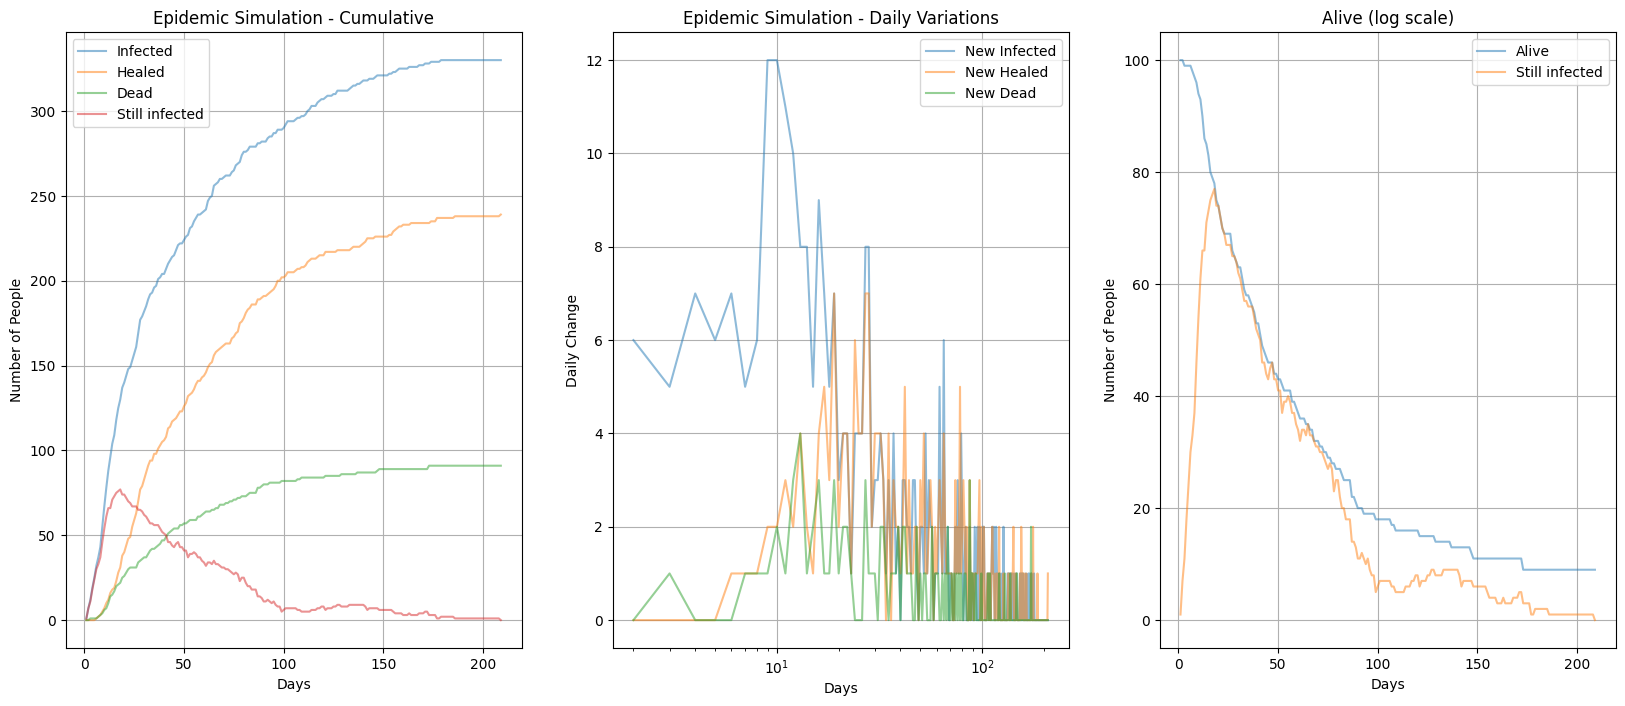

9


In [63]:
pop=Population(N,L, mu, sigma)
for i in range(1000):
    ret=pop.a_day()
    if i%100==0:
        print(f"Day {i+1}", end='')
    if ret==1:
        break
# --- Plot variazioni giornaliere ---
contagions_arr = np.array(pop.contagions)
healings_arr   = np.array(pop.healings)
deaths_arr     = np.array(pop.deaths)

fig= plt.figure(figsize=(20, 8))
plt.subplot(1, 3, 1)
# --- Plot cumulativo ---
day=np.arange(1, len(contagions_arr)+1)
# plt.xscale('log')
plt.plot(day, pop.contagions, label='Infected', alpha=0.5)
plt.plot(day, pop.healings,   label='Healed',   alpha=0.5)
plt.plot(day, pop.deaths,     label='Dead',     alpha=0.5)
plt.plot(day, contagions_arr-healings_arr-deaths_arr, label='Still infected', alpha=0.5)

plt.xlabel('Days')
plt.ylabel('Number of People')
plt.title('Epidemic Simulation - Cumulative')
plt.legend(), plt.grid()

# --- Plot variazioni giornaliere ---
contagions_arr = np.array(pop.contagions)
healings_arr   = np.array(pop.healings)
deaths_arr     = np.array(pop.deaths)


plt.subplot(1, 3, 2)
plt.xscale('log')
plt.plot(day[1:], np.diff(contagions_arr), label='New Infected', alpha=0.5)
plt.plot(day[1:], np.diff(healings_arr),   label='New Healed',   alpha=0.5)
plt.plot(day[1:], np.diff(deaths_arr),     label='New Dead',     alpha=0.5)
plt.xlabel('Days')
plt.ylabel('Daily Change')
plt.title('Epidemic Simulation - Daily Variations')
plt.legend(), plt.grid()

# --- Plot alive (log scale) ---

plt.subplot(1, 3, 3)
# plt.xscale('log')
plt.plot(day, N - deaths_arr, label='Alive', alpha=0.5)
plt.plot(day, contagions_arr-healings_arr-deaths_arr, label='Still infected', alpha=0.5)
plt.xlabel('Days')
plt.ylabel('Number of People')
plt.title('Alive (log scale)')
plt.legend(), plt.grid(), plt.show()

print(pop.N)

Testing pd=0.001 ph=0.001 ph=0.006 ph=0.011 ph=0.016 ph=0.021 ph=0.026 ph=0.031 ph=0.036 ph=0.041 ph=0.045 ph=0.050 ph=0.055 ph=0.060 ph=0.065 ph=0.070 ph=0.075 ph=0.080 ph=0.085 ph=0.090 ph=0.095 ph=0.100 ph=0.105 ph=0.110 ph=0.115 ph=0.120 ph=0.124 ph=0.129 ph=0.134 ph=0.139 ph=0.144 ph=0.149 ph=0.154 ph=0.159 ph=0.164 ph=0.169 ph=0.174 ph=0.179 ph=0.184 ph=0.189 ph=0.194 ph=0.199 ph=0.204 ph=0.208 ph=0.213 ph=0.218 All healthy ph=0.223 ph=0.228 ph=0.233 ph=0.238 ph=0.243 ph=0.248 ph=0.253 ph=0.258 ph=0.263 ph=0.268 ph=0.273 ph=0.278 ph=0.283 ph=0.287 ph=0.292 ph=0.297 ph=0.302 ph=0.307 ph=0.312 ph=0.317 ph=0.322 ph=0.327 ph=0.332 ph=0.337 ph=0.342 ph=0.347 ph=0.352 All healthy ph=0.357 ph=0.362 ph=0.367 ph=0.371 All healthy ph=0.376 ph=0.381 ph=0.386 ph=0.391 All healthy ph=0.396 ph=0.401 ph=0.406 All healthy ph=0.411 All healthy ph=0.416 ph=0.421 ph=0.426 ph=0.431 All healthy ph=0.436 All healthy ph=0.441 ph=0.446 ph=0.450 All healthy ph=0.455 All healthy ph=0.460 All healthy ph=0.

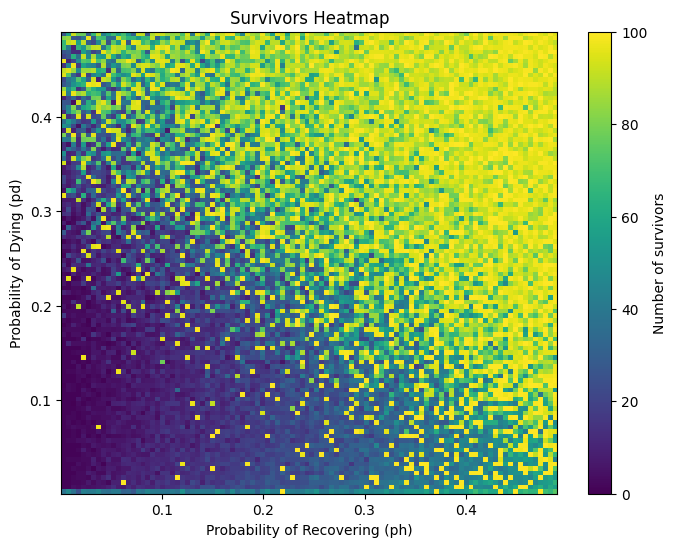

In [69]:
# Parameter ranges

#Input data
N = 100
L = 20
mu = np.array([1]*N)
sigma = np.array([0.1]*N)
ps= 0.9999 #probability of turning sick
d= 2 #distance of contagion
# d**2

pd_values = np.linspace(0.001, 0.49, 100)
ph_values = np.linspace(0.001, 0.49, 100)

# Matrix to store results
survivors_matrix = np.zeros((len(pd_values), len(ph_values)))

# Sweep loop
for i, pd_val in enumerate(pd_values):
    print(f"Testing pd={pd_val:.3f}", end=' ')
    for j, ph_val in enumerate(ph_values):
        
        # Initialize population
        pop = Population(N, L, mu, sigma)
        
        # Update simulation parameters
        pd = pd_val
        ph = ph_val
        print(f"ph={ph:.3f}", end=' ')
        # Run simulation
        for day in range(1000):
            ret = pop.a_day()
            if ret == 1:
                break
    
        # Store final number of survivors
        survivors_matrix[i, j] = pop.N
    print() 
# Plotting the heatmap
plt.figure(figsize=(8, 6))
plt.imshow(survivors_matrix, origin='lower', aspect='auto', cmap='viridis',
           extent=[ph_values[0], ph_values[-1], pd_values[0], pd_values[-1]])
plt.colorbar(label='Number of survivors')
plt.xlabel('Probability of Recovering (ph)')
plt.ylabel('Probability of Dying (pd)')
plt.title('Survivors Heatmap')
plt.show()